**PROJECT CHECKPOINT 2: Research Question Formation**

---

Name: Tyler Hardison
Course: CSCE 676 - 700

In [1]:
import os, io, gzip, zipfile, tarfile, sys, math, random
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import csv

# For reproducibility
random.seed(42)
np.random.seed(42)

print(nx.__version__)
from google.colab import drive
drive.mount('/content/drive')

3.6.1
Mounted at /content/drive


Raw data shape: (110880, 33)
Cleaned data shape: (93820, 11)
Single-factor table shape: (93820, 7)
Combined table shape: (93752, 10)


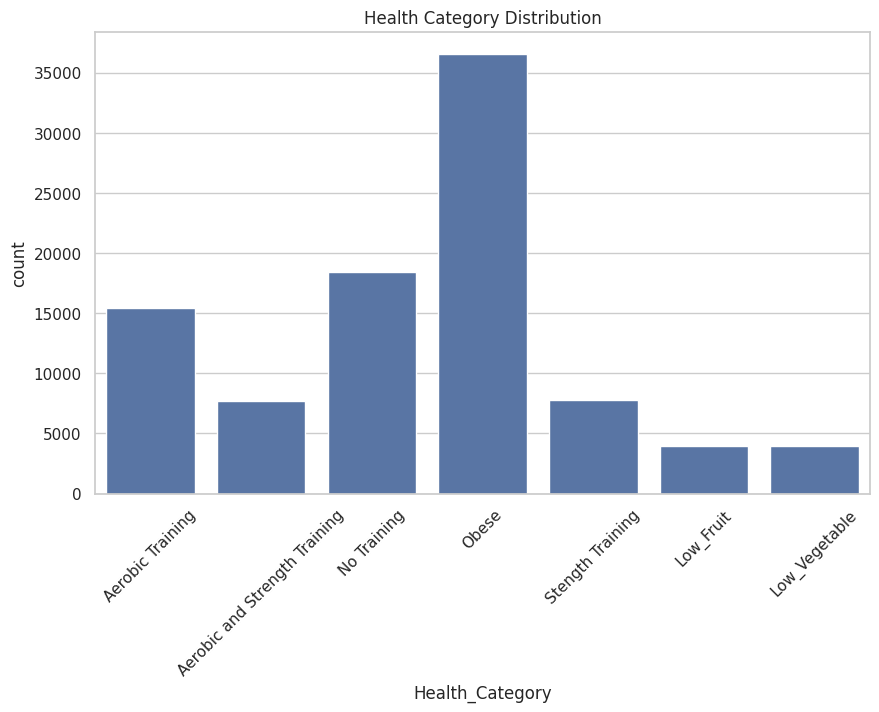

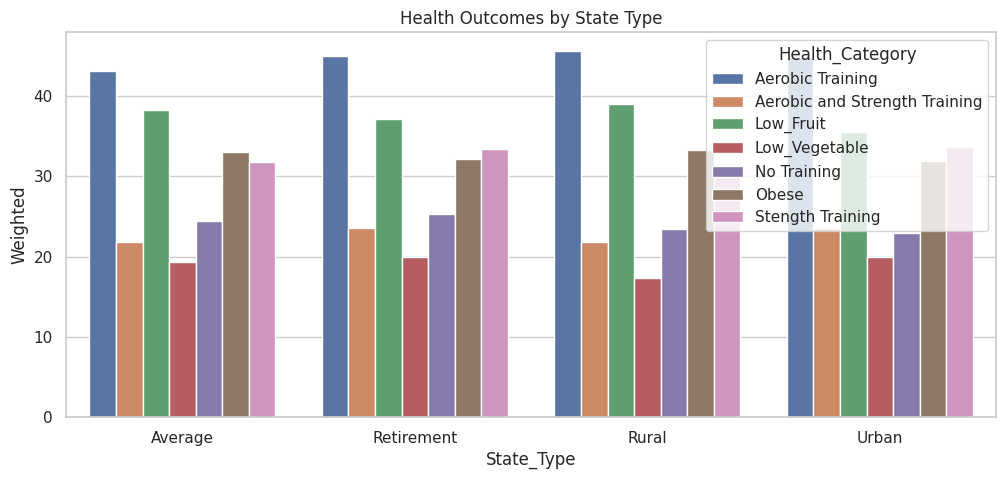

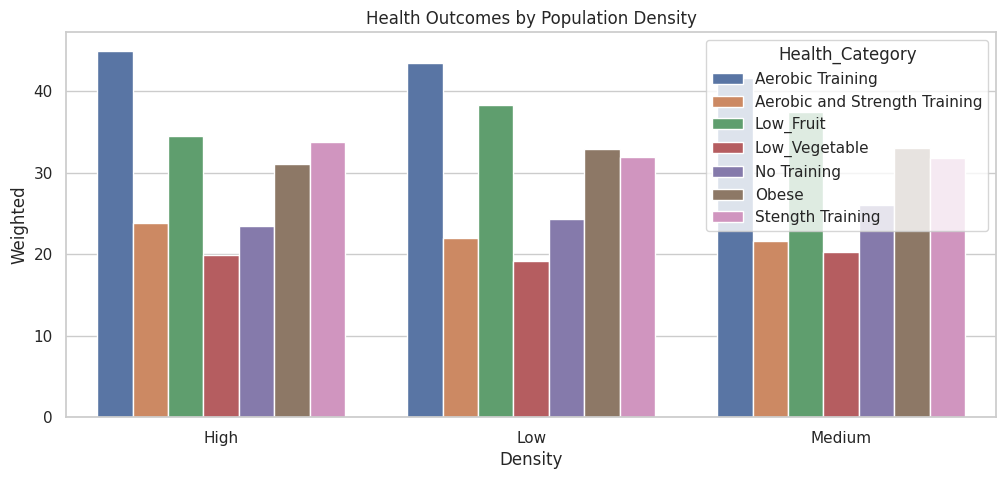

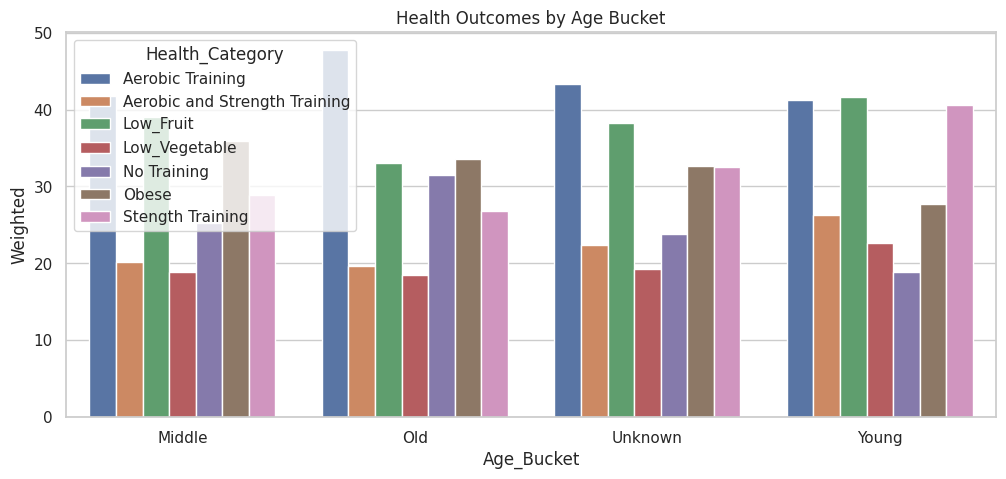

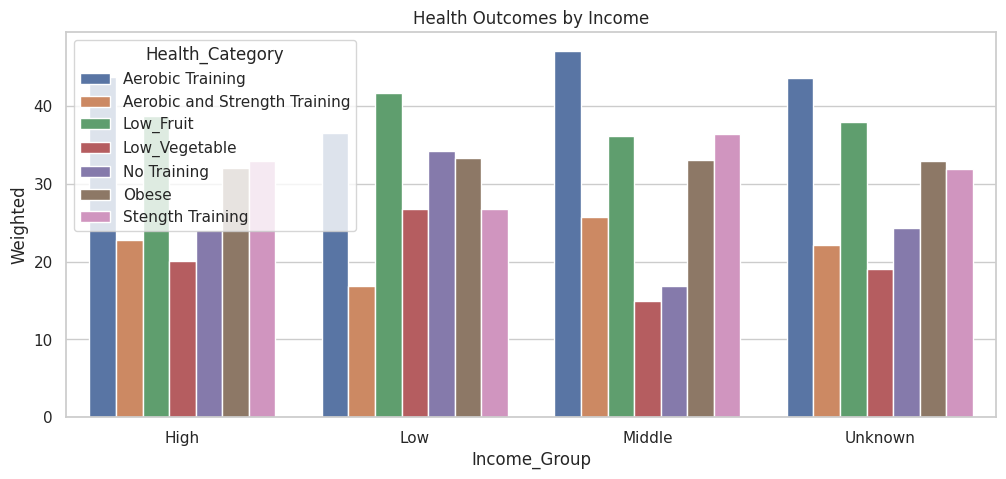


Top 10 States by Obesity Percentage (Weighted):
            State  Weighted_Obese_Percent
52  West Virginia               35.802876
25    Mississippi               35.549649
19      Louisiana               34.974346
3        Arkansas               34.940277
0         Alabama               34.870212
36   North Dakota               34.761577
38       Oklahoma               34.707131
16           Iowa               34.702698
41    Puerto Rico               34.537375
45      Tennessee               34.380565

All Health Categories for Top 10 Obese States:
Health_Category  Aerobic Training  Aerobic and Strength Training  Low_Fruit  \
State                                                                         
Alabama                 36.550745                      16.771799  45.315706   
Arkansas                38.314267                      17.729931  45.468927   
Iowa                    40.736554                      19.884328  38.980779   
Louisiana               37.482576             

In [4]:
import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning)

# ==============================
# IMPORTS
# ==============================
import csv
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

random.seed(42)
np.random.seed(42)
sns.set(style="whitegrid")

# ==============================
# 1. LOAD DATA
# ==============================
def import_dataset(path: str):
    rows = []
    with open(path, newline="", encoding="utf-8") as f:
        reader = csv.reader(f)
        for row in reader:
            rows.append(row)
    df = pd.DataFrame(rows)
    df.columns = df.iloc[0]
    df = df[1:]
    df = df.dropna(axis=1, how='all')
    df = df.loc[:, df.columns.notna()]
    df = df.reset_index(drop=True)
    return df

dataset_path = '/content/drive/MyDrive/CSCE_676/Project/Obesity.csv'
df_raw = import_dataset(dataset_path)
print("Raw data shape:", df_raw.shape)




# ==============================
# 2. CLEAN DATASET
# ==============================
def clean_obesity_dataset(df):
    df = df.copy()
    df = df[df["Data_Value"] != ""]
    df = df[df["Sample_Size"] != ""]
    df = df[df["Stratification1"] != "Total"]

    cols = [
        "YearStart", "LocationDesc", "Question",
        "Data_Value", "Sample_Size",
        "StratificationCategory1", "Stratification1"
    ]
    df = df[cols]

    df = df.rename(columns={
        "YearStart": "Year",
        "LocationDesc": "State",
        "Question": "Health_Variable",
        "Data_Value": "Value_Percent"
    })

    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["Value_Percent"] = pd.to_numeric(df["Value_Percent"], errors="coerce")
    df["Sample_Size"] = pd.to_numeric(df["Sample_Size"], errors="coerce")

    # ---------------------------
    # Health Map (Simplified)
    # ---------------------------
    health_map = {
        "Percent of adults aged 18 years and older who have obesity": "Obese",
        "Percent of adults aged 18 years and older who have an overweight classification": "Obese",
        "Percent of adults who achieve more than 300 minutes a week of moderate-intensity aerobic physical activity or 150 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)": "Aerobic Training",
        "Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic physical activity (or an equivalent combination) and engage in muscle-strengthening activities on 2 or more days a week": "Aerobic and Strength Training",
        "Percent of adults who achieve at least 150 minutes a week of moderate-intensity aerobic physical activity or 75 minutes a week of vigorous-intensity aerobic activity (or an equivalent combination)": "Aerobic Training",
        "Percent of adults who engage in muscle-strengthening activities on 2 or more days a week": "Stength Training",
        "Percent of adults who engage in no leisure-time physical activity": "No Training",
        "Percent of adults who report consuming fruit less than one time daily": "Low_Fruit",
        "Percent of adults who report consuming vegetables less than one time daily": "Low_Vegetable"
    }
    df["Health_Category"] = df["Health_Variable"].map(health_map)


    # ---------------------------
    # Create demographic columns
    # ---------------------------
    demo_cols = ["Sex", "Age_Group", "Income_Group", "Education_Level", "Race"]
    for col in demo_cols:
        df[col] = None


    for idx, row in df.iterrows():
        cat = row["StratificationCategory1"]
        val = row["Stratification1"]
        if cat == "Sex":
            df.at[idx, "Sex"] = val
        elif cat == "Age (years)":
            df.at[idx, "Age_Group"] = val


        elif cat == "Income":
            if "<" in val or "15,000" in val or "25,000" in val:
                df.at[idx, "Income_Group"] = "Low"
            elif "50,000" in val or "75,000" in val:
                df.at[idx, "Income_Group"] = "Middle"
            else:
                df.at[idx, "Income_Group"] = "High"


        elif cat == "Education":
            df.at[idx, "Education_Level"] = val
        elif cat == "Race/Ethnicity":
            df.at[idx, "Race"] = val


    df = df.drop(columns=["StratificationCategory1", "Stratification1"])
    for col in demo_cols:
        df[col] = df[col].astype(str).str.strip().str.replace(" ", "_")
    df = df.reset_index(drop=True)
    return df

df_clean = clean_obesity_dataset(df_raw)
print("Cleaned data shape:", df_clean.shape)



# ==============================
# 3. SINGLE-FACTOR TABLE
# ==============================
demo_cols = ["Sex", "Age_Group", "Income_Group", "Education_Level", "Race"]
rows = []
for _, r in df_clean.iterrows():
    for col in demo_cols:
        val = r[col]

        if val != "None" and val != "":
            rows.append({
                "Year": r["Year"],
                "State": r["State"],
                "Health_Category": r["Health_Category"],
                "Value_Percent": r["Value_Percent"],
                "Sample_Size": r["Sample_Size"],
                "Factor": col,
                "Value": val
            })

df_single = pd.DataFrame(rows)
print("Single-factor table shape:", df_single.shape)




# ==============================
# 4. COMBINED TABLE
# ==============================
group_cols = ["Year", "State", "Health_Category", "Value_Percent", "Sample_Size"]
def combine_group(group):
    result = {}

    for col in demo_cols:
        vals = group[col].dropna().unique()
        vals = [v for v in vals if v != "None"]
        if len(vals) == 0:
            result[col] = "Unknown"
        elif len(vals) == 1:
            result[col] = vals[0]
        else:
            result[col] = "|".join(sorted(vals))
    return pd.Series(result)

df_combined = df_clean.groupby(group_cols).apply(combine_group).reset_index()
print("Combined table shape:", df_combined.shape)




# ==============================
# 5. FEATURE ENGINEERING
# ==============================
urban_states = ["California", "New York", "Texas", "Florida", "Illinois", "New Jersey", "Massachusetts", "Washington"]
rural_states = ["Wyoming", "Montana", "North Dakota", "South Dakota", "West Virginia", "Vermont", "Alaska"]
retirement_states = ["Florida", "Arizona"]


def categorize_state(state):
    if state in retirement_states:
        return "Retirement"
    elif state in urban_states:
        return "Urban"
    elif state in rural_states:
        return "Rural"
    else:
        return "Average"
df_combined["State_Type"] = df_combined["State"].apply(categorize_state)


high_density = ["New Jersey", "Massachusetts", "California", "New York"]
medium_density = ["Texas", "Florida", "Illinois", "Pennsylvania"]



def density_bucket(state):
    if state in high_density:
        return "High"
    elif state in medium_density:
        return "Medium"
    else:
        return "Low"
df_combined["Density"] = df_combined["State"].apply(density_bucket)



young_ages = ["18_-_24", "25_-_34"]
middle_ages = ["35_-_44", "35_-_44/45_-_54", "45_-_54", "55_-_64"]
def age_bucket(age):
    if age == "Unknown":
        return "Unknown"
    elif age in young_ages:
        return "Young"
    elif age in middle_ages:
        return "Middle"
    else:
        return "Old"
df_combined["Age_Bucket"] = df_combined["Age_Group"].apply(age_bucket)





# ==============================
# 6. EDA
# ==============================
def weighted_mean(x):
    return np.average(x["Value_Percent"], weights=x["Sample_Size"])

# Health Category Distribution
plt.figure(figsize=(10,6))
sns.countplot(data=df_combined, x="Health_Category")
plt.title("Health Category Distribution")
plt.xticks(rotation=45)
plt.show()

# State Type vs Health
agg = df_combined.groupby(["State_Type", "Health_Category"]).apply(weighted_mean).reset_index(name="Weighted")
plt.figure(figsize=(12,5))
sns.barplot(data=agg, x="State_Type", y="Weighted", hue="Health_Category")
plt.title("Health Outcomes by State Type")
plt.show()

# Population Density vs Health
agg = df_combined.groupby(["Density", "Health_Category"]).apply(weighted_mean).reset_index(name="Weighted")
plt.figure(figsize=(12,5))
sns.barplot(data=agg, x="Density", y="Weighted", hue="Health_Category")
plt.title("Health Outcomes by Population Density")
plt.show()

# Age Bucket vs Health
agg = df_combined.groupby(["Age_Bucket", "Health_Category"]).apply(weighted_mean).reset_index(name="Weighted")
plt.figure(figsize=(12,5))
sns.barplot(data=agg, x="Age_Bucket", y="Weighted", hue="Health_Category")
plt.title("Health Outcomes by Age Bucket")
plt.show()

# Income vs Health
agg = df_combined.groupby(["Income_Group", "Health_Category"]).apply(weighted_mean).reset_index(name="Weighted")
plt.figure(figsize=(12,5))
sns.barplot(data=agg, x="Income_Group", y="Weighted", hue="Health_Category")
plt.title("Health Outcomes by Income")
plt.show()





# ==============================
# 7. OP 10 STATES BY OBESITY RATE (WEIGHTED)
# ==============================

# Filter to only Obese rows
df_obese = df_single[df_single["Health_Category"] == "Obese"]

# Compute weighted obesity percentage per state
state_weighted = df_obese.groupby("State").apply(
    lambda x: np.average(x["Value_Percent"], weights=x["Sample_Size"])
).reset_index(name="Weighted_Obese_Percent")

# Merge back with single-factor table to get other health categories
state_health = df_single.groupby(["State", "Health_Category"]).apply(
    lambda x: np.average(x["Value_Percent"], weights=x["Sample_Size"])
).reset_index(name="Weighted_Percent")

# Get top 10 states by obesity %
top10_states = state_weighted.sort_values("Weighted_Obese_Percent", ascending=False).head(10)
print("\nTop 10 States by Obesity Percentage (Weighted):")
print(top10_states)

# Optional: show all health categories for these top 10 states
top10_state_list = top10_states["State"].tolist()
top10_health = state_health[state_health["State"].isin(top10_state_list)].pivot(
    index="State", columns="Health_Category", values="Weighted_Percent"
).fillna(0)
print("\nAll Health Categories for Top 10 Obese States:")
print(top10_health)






# ==============================
# 8. APRIORI / ASSOCIATION RULES (OBESE ONLY)
# ==============================
min_support = 0.3
min_confidence = 0.6

# Only keep rows that are Obese
df_obese_only = df_combined[df_combined["Health_Category"] == "Obese"]

for demo in demo_cols:
    # Prepare transactions
    transactions = []
    for _, row in df_obese_only.iterrows():
        if row[demo] == "Unknown":
            continue
        # Repeat the transaction for the sample size (weighting)
        repeat = int(row["Sample_Size"])
        for _ in range(repeat):
            basket = [
                f"Health=Obese",
                f"{demo}={row[demo]}"
            ]
            transactions.append(basket)

    if len(transactions) == 0:
        print(f"No valid transactions for {demo}")
        continue

    # One-hot encode
    te = TransactionEncoder()
    df_encoded = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)

    # Frequent itemsets
    frequent_itemsets_all = apriori(df_encoded, min_support=min_support, use_colnames=True)

    if frequent_itemsets_all.empty:
        print(f"No frequent itemsets for {demo}")
        continue

    # Filter for display (>=2 items)
    frequent_itemsets_display = frequent_itemsets_all[frequent_itemsets_all["itemsets"].apply(lambda x: len(x) >= 2)]

    print(f"\n================ {demo.upper()} (OBESE ONLY) =================")
    print("Frequent Itemsets (>=2 items):")
    print(frequent_itemsets_display.sort_values("support", ascending=False).head(10))

    # Generate association rules using **all frequent itemsets**
    try:
        rules = association_rules(frequent_itemsets_all, metric="confidence", min_threshold=min_confidence)
    except KeyError as e:
        print(f"Skipping association rules for {demo}: {e}")
        continue

    # Filter rules for health in consequent (should all be Obese)
    rules_filtered = rules[
        rules['consequents'].apply(lambda x: any("Health=" in i for i in x)) &
        (rules['antecedents'].apply(len) + rules['consequents'].apply(len) >= 2)
    ].sort_values(['lift', 'confidence'], ascending=False)

    if rules_filtered.empty:
        print("No valid rules found for this demographic.\n")
        continue

    print("\nTop Health Association Rules (Obese Only):")
    for _, r in rules_filtered.head(10).iterrows():
        lhs = ", ".join(list(r["antecedents"]))
        rhs = ", ".join(list(r["consequents"]))
        print(f"{lhs}  --->  {rhs} | Support: {r['support']:.3f}, Confidence: {r['confidence']:.3f}, Lift: {r['lift']:.3f}")



**RECAP OF PREPARATIONS - CLEANING THE DATA AND PERFORMING EDA**


---

***Method***

* ***Dataset*** - the dataset selected is a survey conducted in 2025 by the U.S. Department of Health and Human Services over Nutrition, Physical Activity, and Obesity. It tracks behavioral risk factors and health status amongst a large array of participants across the country and our territories. Key attributes include sex, age, race, income, education and location. Given such a large selection of datapoints, I believe that this dataset will be able to yield a various conclusions based on singletons or combinations of these attributes. In addition, survey answers are standardized, no free response. This helps with cleaning the data signifincantly as it allows us to find all unique values for a particular attriubte without being concerned about excessive outcomes, as well as gives the analysis a foundation for creating assumptions and other distintions without being concerned of variant or outlying answer types. Given this nature of the data, I was able to also narrow down categories with a larger range of answers (such as age) to more broad and concise, bucketed, responses (age: young, middle, old). In cleaning the data, I account for this by bucketing the actual health patterns and later bucket the different answers to each attribute (this is to maintain the ability to breakdown attributes even after finding support of broad factor contributions in analysis.

* ***Techniques*** - as previously mentioned, in my initial preparation of the data, I used a bucketing technique to make cateogires less variable and allow for a more meaningful analysis based on common qualities between traits (such as obese and overweight being similar qualities for the sake of this project). This helps greatly when we get into the EDA as it also helps with the technique of finding frequent itemsets with the Apriori algorithm. I hope to also be able to use these more broad categories to help a one dimensional convulutional neural network model create plots for clustering. I believe that at the end of this, a cluster plot will help tremdendously and finding what terminologies can often be link together more. Perhaps using sample_sizes and value_percentage, this can assist in finding the density of health factors and how they may help predict health outcomes for a particular group, and how they may differ for various demographics, which will be accomplished by subspace-clustering (MAFIA).

In Short:

    Internal Techniques
    * Bucketing
    * Frequent Itemsets
    * Apriori Algorithm
    * Clustering

    External Techniques
    * Subspace Clustering
    * Trajectory Clustering
    * Convulutional Neural Network


**Design**

As a recap, my code desing builds off of the import of the inital datafile, with standardarized variables. I exclude NA columns and then clean the data from there. In order to clean that data, I first sought distinct values from each columns and worked to form buckets to categorize those unique values in. These buckets help narrow down some of the lengthier survey answers while also maintaining well strutured, meaningful input. I mapped these values by using lists of bucket values. These bucket values were created based on a manual, custom range and may be adjusted as the analysis needs. To provide an example, states are listed as rural, urban, etc. as well as broken out by density. If other a state skews data or may need to be listed in another category, it can be easily moved. From there, the plots of each of these attributes are provided and then I go into my EDA, utiliziing an Apriori algorithm. This algorithm makes use of the sample_size and value_percent columns in order to provided accurate weighted results for each test category. For the purpose of the algorithm, I also use a minimum of an itemset size of 2 in order to find associations rules. Lastly, I conducted this specific search for association rules based only on data where the health status was obese or overweight, in order to remove any other associations for now. This is why they will always have 100% confidence here - it is currenlty just viewing the strongest percentage weights for each group.

***Parameters***

*   ***min_support*** - the dataset does not have very many largely supported itemsets, however, it does provide moderate support with a 30% minimum. Listing the top 10, we still get a good view of what we are working with.

*   ***min_confidence*** - when looking for rules, we want them to be reliably accurate, which is why I opted for a higher support threshold of 60% when searching for association rules.

**Results**

Please see Intial Insights and Direction

**Reflection**

Please see Intial Insights and Direction

**INITIAL INSIGHTS AND DIRECTION**


---

***Summary of Observations***

On initial interpretation of the outcomes, it appears that most of the worst health scores are scattered around more rural and midwestern/southern states such as West Virginia, Mississippi and Louisiana. What these state have in common is a relatively high amount of people that have no workout plan at all, and those that do focuse less on strength training and heave less healthy diets.

Looking at the attributes of the surveys, if we filter to only analyze those that reported being Obese or Overweight (in the Obesity bucket), then this provides us with data to see what demographics in which health factors have the most support. The frequent itemsets include 'Obese' as a key attribute, paired with one other attribute. This ensures that we are looking at the support directly of what factor yields being obese or overweight.

**Hypothesis**

I feel that there will be a connection between income and education level as they pertain to obesity / overweight population statistics. Additionally, this would also contribute to the reason why most of the worst health scores are focused in more of the moderately populated but more rural states and regions. I believe this is a contributing factor, because typically people with higher income and education are likely moving to major hub cities for work. Likewise, psychologically, there could be connection between educational / economic status that is an indicator of the drive and determination that typically accompanies a more fit lifestyle.


**RESEARCH QUESTIONS**


---



***RESEARCH QUESTION 1: What health factors are most influential in determining obesity? Not to be confused with indicative.***



---


***Motivation and Feasibility***
- Motivation - as seen by the minimalist itemsets provided by the EDA, the data is far more nuanced than just being able to say "if this, then that." There are several factors at play here, and while some of them may not have direct causation, there is likely to be relationships that we can dig up across categories that might still prove to have a factor of influence in the matter. Perhaps we may even find influence between attributes in of themselves.

- Technique to Employ - Clustering


- Feasibility - the data structure is built for clustoring. I have engineered it as well in order to create more concise groups to analyze and provide more telling influence patterns.

- Risks - Trajectory clustoring may be slow due to running the same process accross multiple iterations. This may require a lot of computational costs



***Method Planning***

- Course Algorithms - Random Forest

- External Algorithms - Trajectory Clustoring

- Evaluation - Influence percentage will be used as a factor of determining what health factors provide the most importance to determination of Obesity as well as Gini Impurity, to see what features decrease weight in impurity.

- Baselines - View factors with high support only and then all factors together.


***RESEARCH QUESTION 2: Do different health factors have different levels of influence dependending on the demographic? How do these health factors work together?***

---


***Motivation and Feasibility***
- Motivation - building off of the previous question, this is an essential question to ask. As we can see by the top 10 list provided by weighted percentage values from attributes, we can see that similar states have similar statistics. The question I want to answer is how do the the other health statistics vary based on factors like geolocation?" For instance, if someone is in a certain region of the country, perhaps income matters less. Maybe more population dense regions provide access to better resources and community for morale?

- Technique to Employ - Regression Analysis, Frequest Itemsets, Clustering

- Feasibility - The itemset is built to do this. There are different tables, one of which maintains original sub-groups within each attribute. Easily modeled just like the first question.

- Risks - It may be slightly cumbersome to analyze regression as it will require breaking out multiple pairs or groups to find stronger influence, being that there are so many attributes.


***Method Planning***
- Course Algorithms - Apriori, Itemsets, KMeans / DBSCAN

- External Algorithms - Linear Regression

- Evaluation - Itemsets will be ranked on confidence levels and attributes will be assessed by their coorelating subgroups within a graph. Furthermore, the volatility of a specific category to affect obesity percentage will be determined by the regression cooefficient.

- Baselines - Clusters in the previous random forest and certain attribute influence will be used to determine what attributes to breakout further. If a health factor has a higher influence, we want to see what sub-groups within that category carry more weight.

***RESEARCH QUESTION 3: Is it possible to train a ML model to predict a health outcome based on health attributes and activity alone? Do deviations exist and can we infer oppositions to existing data?***

---


***Motivation and Feasibility***
- Motivation - A lot of the charts have data that is very similar amongst health attributes. This would make it appear that being able to predict outcomes of datasets would be difficult. Perhaps after answering the previous two quesitons, there are layers to unfold that we can use to train a neural netwrok to begin a deep learning model based on key influencers we may find.

- Technique to Employ - 1 Dimensional Convolutional Neural Network

- Feasibility - there will be a learning curve to the algorithms, but they are implementable. Each is desinged for robust analysis, and gradient boost especially for interpreting mult-factorial sets such as this.

- Risks - Neural network may overfit the dataset, but it is relatively small, so it should be okay to process.


***Method Planning***
- Course Algorithms - N/A

- External Algorithms - Neural Network, 1D CNN, Gradient Boost

- Evaluation - test how accurately these models are able to label data and see if they develop clusters compared to expectation.

- Baselines - test with both the whole data set and a random subset


\begin{array}{|c|l|l|}
\hline
\textbf{RQ} & \textbf{Technique} & \textbf{Course vs External} \\
\hline
1 & Random Forest & Internal \\
1 & Trajectory Clustering & External \\
2 & Apriori & Internal \\
2 & KMeans / DBSCAN & Internal \\
2 & Linear Regression & External \\
3 & CNN & External \\
3 & Gradient Boost & External \\
\hline
\end{array}


**GITHUB PORTFOLIO BUILDING**


---


Please see the link below to navigate to my github repository for this project:

https://github.com/tyhardison/Data-Analytics-Project---Health-Variables.git




***Resources***


---

**Collaborators**

- None

**Web Sources**

- https://www.w3schools.com/python/matplotlib_pyplot.asp

- U.S. Department of Health & Human Services. (2025, December 13). Nutrition, Physical Activity, and Obesity – Behavioral Risk Factor Surveillance System. Catalog.Data.gov. Retrieved [insert date you accessed], from https://catalog.data.gov/dataset/nutrition-physical-activity-and-obesity-behavioral-risk-factor-surveillance-system



**AI Tools**

- I used ChatGPT to help me with this portion. Taking my code from project checkpoint 1, I provided chatGPT and gave it a set of goals I wanted to achieve with it. While previously, not well structured, I decided on the idea to bucket certain categories to provide a more concise analysis. In addition, I also told it to be sure to provide a weighted Apriori algorithm that would yield meaningful results. This allowed me to clean it up and prepare it for later use in clustering analyses.

**Citations**

- None